# Phase 3: Machine Learning Model

In [9]:
import pandas as pd

file_path = "Telco_customer_churn.xlsx"  # change to your actual file path
df = pd.read_excel(file_path)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

1. Logistic Regression (baseline) 

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Select target and features
y = df['Churn Value']
X = df.drop(['CustomerID', 'Churn Label', 'Churn Value', 'Churn Reason', 'Churn Score', 'CLTV', 'Lat Long', 'Latitude', 'Longitude', 'Country', 'Count'], axis=1)

# Convert categorical → dummy variables
X = pd.get_dummies(X, drop_first=True)

# FIX: Ensure all columns are numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model training
model = LogisticRegression(max_iter=2000, random_state=42)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values('Importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importance.head(10))


Accuracy: 0.7478
Precision: 0.5650
Recall: 0.4065
F1 Score: 0.4728
ROC-AUC: 0.7646

Top 10 Feature Importances:
                           Feature  Importance
1138  Internet Service_Fiber optic    0.591893
1154         Paperless Billing_Yes    0.532136
1131                   Gender_Male    0.439654
58                City_Bakersfield    0.422318
491                    City_Kyburz    0.401926
1132            Senior Citizen_Yes    0.397055
462                   City_Jackson    0.375300
1351           Total Charges_50.45    0.342171
219                  City_Corcoran    0.336097
794                    City_Pomona    0.326361


Random Forest 

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf_proba)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1 Score: {f1_rf:.4f}")
print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")

rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Random Forest Feature Importances:")
print(rf_feature_importance.head(10))

Random Forest Accuracy: 0.8027
Random Forest Precision: 0.7165
Random Forest Recall: 0.4813
Random Forest F1 Score: 0.5758
Random Forest ROC-AUC: 0.8528

Top 10 Random Forest Feature Importances:
                              Feature  Importance
1                       Tenure Months    0.091043
2                     Monthly Charges    0.056113
0                            Zip Code    0.048919
1138     Internet Service_Fiber optic    0.024965
1153                Contract_Two year    0.022181
1134                   Dependents_Yes    0.021429
1156  Payment Method_Electronic check    0.020750
1141              Online Security_Yes    0.018981
1152                Contract_One year    0.016045
1147                 Tech Support_Yes    0.015503


XGBoost

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_pred_xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb_proba)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Precision: {precision_xgb:.4f}")
print(f"XGBoost Recall: {recall_xgb:.4f}")
print(f"XGBoost F1 Score: {f1_xgb:.4f}")
print(f"XGBoost ROC-AUC: {roc_auc_xgb:.4f}")

xgb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 XGBoost Feature Importances:")
print(xgb_feature_importance.head(10))

C:\Users\parim\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [20:42:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8069
XGBoost Precision: 0.6772
XGBoost Recall: 0.5850
XGBoost F1 Score: 0.6277
XGBoost ROC-AUC: 0.8640

Top 10 XGBoost Feature Importances:
                              Feature  Importance
1138     Internet Service_Fiber optic    0.215722
1153                Contract_Two year    0.194761
1152                Contract_One year    0.102386
1139              Internet Service_No    0.052963
1134                   Dependents_Yes    0.036471
1                       Tenure Months    0.028507
1151             Streaming Movies_Yes    0.022911
1137               Multiple Lines_Yes    0.017586
1154            Paperless Billing_Yes    0.016357
1156  Payment Method_Electronic check    0.016048


CatBoost

In [16]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

cat.fit(X_train_scaled, y_train)

y_pred_cat = cat.predict(X_test_scaled)
y_pred_cat_proba = cat.predict_proba(X_test_scaled)[:, 1]

accuracy_cat = accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat)
recall_cat = recall_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)
roc_auc_cat = roc_auc_score(y_test, y_pred_cat_proba)

print(f"CatBoost Accuracy: {accuracy_cat:.4f}")
print(f"CatBoost Precision: {precision_cat:.4f}")
print(f"CatBoost Recall: {recall_cat:.4f}")
print(f"CatBoost F1 Score: {f1_cat:.4f}")
print(f"CatBoost ROC-AUC: {roc_auc_cat:.4f}")

cat_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 CatBoost Feature Importances:")
print(cat_feature_importance.head(10))

CatBoost Accuracy: 0.8022
CatBoost Precision: 0.6840
CatBoost Recall: 0.5374
CatBoost F1 Score: 0.6019
CatBoost ROC-AUC: 0.8648

Top 10 CatBoost Feature Importances:
                               Feature  Importance
1                        Tenure Months   20.064118
1134                    Dependents_Yes   19.388672
1153                 Contract_Two year   15.077216
1152                 Contract_One year    8.071522
1138      Internet Service_Fiber optic    7.149832
1146  Tech Support_No internet service    5.581331
2                      Monthly Charges    4.213155
1156   Payment Method_Electronic check    2.691807
0                             Zip Code    2.569570
1154             Paperless Billing_Yes    1.987893


Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_dt_proba = dt.predict_proba(X_test)[:, 1]

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_dt_proba)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Precision: {precision_dt:.4f}")
print(f"Decision Tree Recall: {recall_dt:.4f}")
print(f"Decision Tree F1 Score: {f1_dt:.4f}")
print(f"Decision Tree ROC-AUC: {roc_auc_dt:.4f}")

dt_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Decision Tree Feature Importances:")
print(dt_feature_importance.head(10))

Decision Tree Accuracy: 0.7596
Decision Tree Precision: 0.5781
Decision Tree Recall: 0.5034
Decision Tree F1 Score: 0.5382
Decision Tree ROC-AUC: 0.6809

Top 10 Decision Tree Feature Importances:
                                     Feature  Importance
1                              Tenure Months    0.201214
1138            Internet Service_Fiber optic    0.102544
0                                   Zip Code    0.101219
2                            Monthly Charges    0.074054
1134                          Dependents_Yes    0.029910
1156         Payment Method_Electronic check    0.017207
1137                      Multiple Lines_Yes    0.014934
1131                             Gender_Male    0.014281
1154                   Paperless Billing_Yes    0.013458
1155  Payment Method_Credit card (automatic)    0.010383


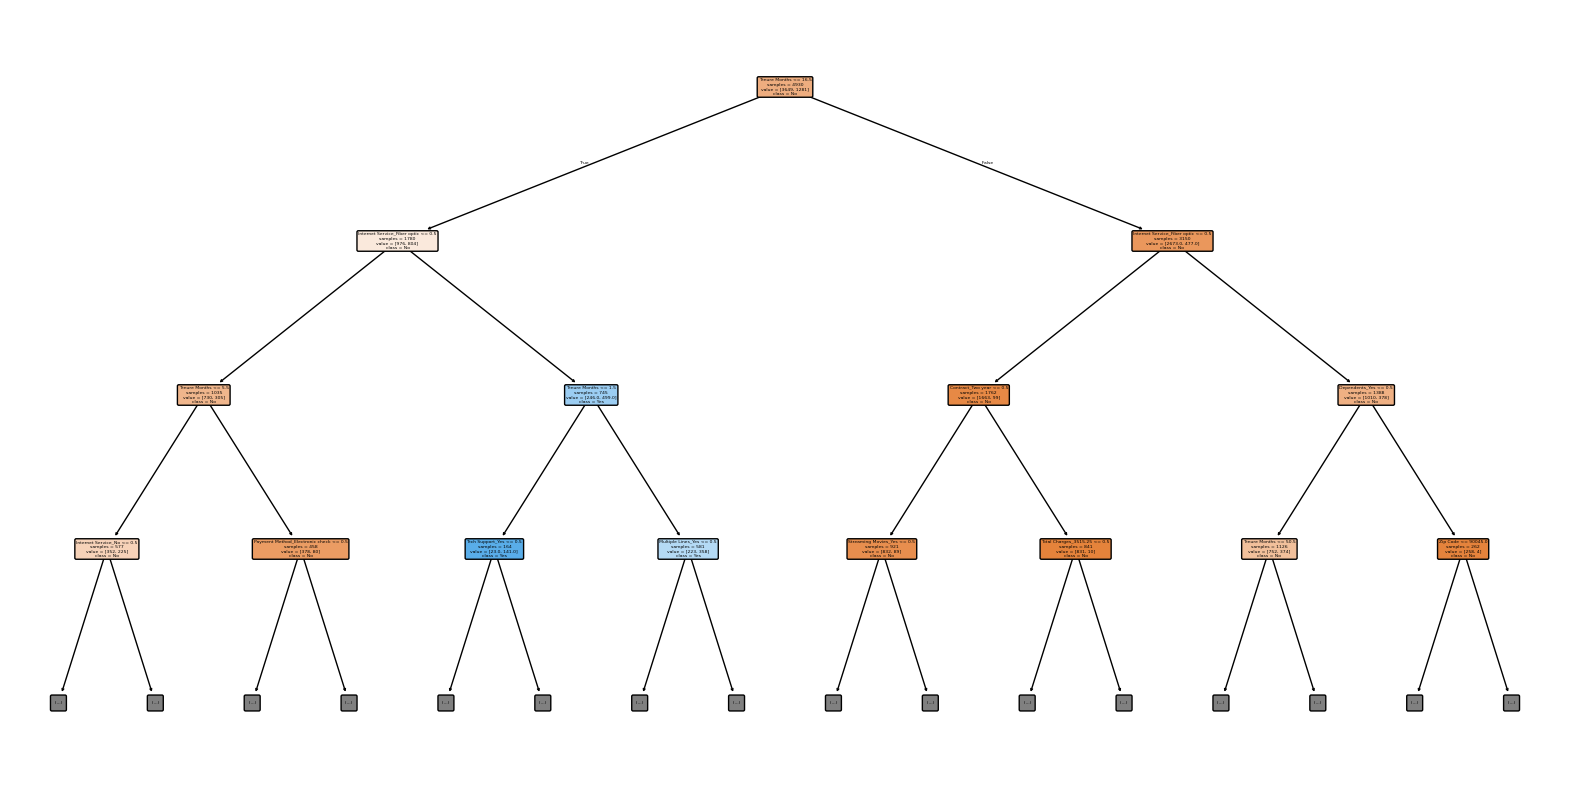

In [18]:
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    impurity=False,
    max_depth=3
)
plt.show()

AdaBoost 

In [19]:
from sklearn.ensemble import AdaBoostClassifier

adb = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

adb.fit(X_train_scaled, y_train)

y_pred_adb = adb.predict(X_test_scaled)
y_pred_adb_proba = adb.predict_proba(X_test_scaled)[:, 1]

accuracy_adb = accuracy_score(y_test, y_pred_adb)
precision_adb = precision_score(y_test, y_pred_adb)
recall_adb = recall_score(y_test, y_pred_adb)
f1_adb = f1_score(y_test, y_pred_adb)
roc_auc_adb = roc_auc_score(y_test, y_pred_adb_proba)

print(f"AdaBoost Accuracy: {accuracy_adb:.4f}")
print(f"AdaBoost Precision: {precision_adb:.4f}")
print(f"AdaBoost Recall: {recall_adb:.4f}")
print(f"AdaBoost F1 Score: {f1_adb:.4f}")
print(f"AdaBoost ROC-AUC: {roc_auc_adb:.4f}")

adb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': adb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 AdaBoost Feature Importances:")
print(adb_feature_importance.head(10))

AdaBoost Accuracy: 0.7993
AdaBoost Precision: 0.6889
AdaBoost Recall: 0.5085
AdaBoost F1 Score: 0.5851
AdaBoost ROC-AUC: 0.8588

Top 10 AdaBoost Feature Importances:
                               Feature  Importance
1                        Tenure Months    0.337243
1134                    Dependents_Yes    0.113953
1153                 Contract_Two year    0.073595
1138      Internet Service_Fiber optic    0.071786
1156   Payment Method_Electronic check    0.047866
1154             Paperless Billing_Yes    0.038175
1152                 Contract_One year    0.034929
2                      Monthly Charges    0.034688
944                   City_Smith River    0.031942
1148  Streaming TV_No internet service    0.030702
